In [1]:
import torchvision 
from torchvision import transforms
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]
)
tr_ds=torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)
tr_ds=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [2]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
#초기화
def trunc_normal_(t, mean=0.0, std=1.0):
    with torch.no_grad():
        size = t.shape
        tmp = t.new_empty(size + (4,)).normal_()
        valid = (tmp < 2) & (tmp > -2)
        ind = valid.max(-1, keepdim=True)[1]
        t.data.copy_(tmp.gather(-1, ind).squeeze(-1))
        t.data.mul_(std).add_(mean)
        return t

In [4]:
#입력:(B,C,H,W)->출력 (B,N,D)
#N=>(H/ps)*(W/ps)
class PatchEmbed(nn.Module):
    def __init__(self, img_size = 224, patch_size = 16, in_chans = 3, embed_dim = 768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = self.img_size // self.patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):  # 패치분할 + 선형투영
        x = self.proj(x)                   # (B, D, H/ps, W/ps)
        x = x.flatten(2).transpose(1, 2)   # (B, N, D)
        return x

class MLP(nn.Module):#토큰별 비선형 변환
    def __init__(self, dim, mlp_ratio = 4.0, drop = 0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x
#멀티 해드 어탠션
class Attention(nn.Module):
    def __init__(self, dim, num_heads = 12, qkv_bias = True, attn_drop = 0.0, proj_drop = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        self.last_attn = None  # (B, heads, N, N)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        q = q.permute(0, 2, 1, 3)  # (B, heads, N, d)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        self.last_attn = attn

        x = attn @ v
        x = x.transpose(1, 2).reshape(B, N, -1)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x
        
class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio= 4.0, qkv_bias = True, drop = 0.0, attn_drop = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, eps=1e-6)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim, eps=1e-6)
        self.mlp = MLP(dim, mlp_ratio=mlp_ratio, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [5]:
class ViT(nn.Module):
    def __init__(
        self,
        img_size = 224,
        patch_size = 16,
        in_chans = 3,
        num_classes = 1000,
        embed_dim = 768,
        depth = 12,
        num_heads = 12,
        mlp_ratio = 4.0,
        drop_rate = 0.0,
        attn_drop_rate = 0.0,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.num_features = embed_dim  

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True, drop=drop_rate, attn_drop=attn_drop_rate)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim, eps=1e-6)
        self.head = nn.Linear(embed_dim, num_classes)

        self.apply(self._init_weights)
        trunc_normal_(self.pos_embed, std=0.02)
        trunc_normal_(self.cls_token, std=0.02)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward_features(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x[:, 0]

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

def vit_tiny(img_size=224, patch_size=16, num_classes=10):
    return ViT(img_size=img_size, patch_size=patch_size, embed_dim=192, depth=12, num_heads=3, num_classes=num_classes)


In [6]:
import torchvision
from torchvision import transforms, datasets

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_ds_loader():
    tr_ds = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    tt_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    tr_loader = torch.utils.data.DataLoader(tr_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
    tt_loader = torch.utils.data.DataLoader(tt_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    return tr_ds, tt_ds, tr_loader, tt_loader

In [7]:
tr_ds,tt_ds,tr_ds_loader,tt_ds_loader=get_ds_loader()

Files already downloaded and verified
Files already downloaded and verified


In [8]:
img,label=next(iter(tt_ds_loader))
img,label=img.to(DEVICE),label.to(DEVICE)
img.shape,label.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))

In [9]:
m=vit_tiny(num_classes=10).to(DEVICE)
m.eval()

from collections import defaultdict
activations = {}
attentions = defaultdict(list)

def save_activation(name):
    def hook(m, i, o):
        activations[name] = o.detach().cpu()
    return hook

def save_attn(block_idx):
    def hook(m, i, o):
        if hasattr(m.attn, 'last_attn') and m.attn.last_attn is not None:
            attentions[block_idx].append(m.attn.last_attn.detach().cpu())
    return hook

h_hooks = []
h_hooks.append(m.patch_embed.register_forward_hook(save_activation('patch_embed_out')))
for bi, blk in enumerate(m.blocks):
    h_hooks.append(blk.register_forward_hook(save_attn(bi)))

with torch.no_grad():
    _= m(img)
print(activations.keys())
print(attentions.keys())

dict_keys(['patch_embed_out'])
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


In [10]:
attentions[0]

[tensor([[[[0.0046, 0.0048, 0.0048,  ..., 0.0053, 0.0054, 0.0053],
           [0.0050, 0.0053, 0.0051,  ..., 0.0046, 0.0050, 0.0052],
           [0.0050, 0.0053, 0.0050,  ..., 0.0045, 0.0050, 0.0052],
           ...,
           [0.0051, 0.0050, 0.0052,  ..., 0.0054, 0.0050, 0.0049],
           [0.0051, 0.0047, 0.0049,  ..., 0.0058, 0.0052, 0.0051],
           [0.0051, 0.0049, 0.0051,  ..., 0.0054, 0.0051, 0.0050]],
 
          [[0.0053, 0.0049, 0.0050,  ..., 0.0051, 0.0050, 0.0052],
           [0.0049, 0.0054, 0.0054,  ..., 0.0048, 0.0047, 0.0049],
           [0.0048, 0.0054, 0.0055,  ..., 0.0048, 0.0047, 0.0049],
           ...,
           [0.0050, 0.0051, 0.0050,  ..., 0.0051, 0.0053, 0.0051],
           [0.0056, 0.0046, 0.0045,  ..., 0.0054, 0.0056, 0.0053],
           [0.0055, 0.0046, 0.0045,  ..., 0.0053, 0.0055, 0.0054]],
 
          [[0.0054, 0.0055, 0.0055,  ..., 0.0047, 0.0049, 0.0049],
           [0.0050, 0.0051, 0.0050,  ..., 0.0051, 0.0050, 0.0051],
           [0.0051, 0.00

In [11]:
def denorm_for_vit(img):
    x=img.detach().cpu()
    x=(x-x.min())/(x.max()-x.min()+1e-6)
    return x
    
def show_img_with_patches(img,patch_size=16):
    x=denorm_for_vit(img).permute(1,2,0).numpy()
    H,W=x.shape[:2]
    plt.figure()
    plt.imshow(x)
    for r in range(0,H,patch_size):
        plt.axhline(r,linewidth=0.5)
    for c in range(0,W,patch_size):
        plt.axvline(c,linewidth=0.5)
    plt.title('grid')
    plt.axis('off')
    plt.show()
    
def pca_project_to_rgb(tokens):
    X=tokens-tokens.mean(0,keepdims=True)
    U,S,Vt=np.linalg.svd(X,full_matrices=False)
    proj=X@Vt[:3].T#(N,3)
    proj=(proj - proj.min())/(proj.max()-proj.min())
    return proj

def show_patch_embedding_as_image(patch_tokens,grid_h,grid_w):
    proj=pca_project_to_rgb(patch_tokens)
    img=proj.reshape(grid_h,grid_w,3)
    plt.figure()
    plt.imshow(img)
    plt.title('Patch Embeddings (PCA->RGB)')
    plt.axis("off")
    plt.show()

def show_attention_map(attn,head=0,cls_to_patches=True, grid_h=14,grid_w=14):
    if cls_to_patches:
        weights=attn[0,1:]
    else:
        p=1
        weights=attn[p,1:]
    weights = (weights-weights.min())/(weights.max()-weights.min())
    hest = weights.reshape(grid_h,grid_w)
    plt.figure()
    plt.imshow(hest)
    plt.title("attn heatmap CLS->patches")
    plt.axis('off')
    plt.show()

def attention_rollout(attn_list):
    rollout=np.eye(attn_list[0].shape[0])
    for A in attn_list:
        A_hat=A+np.eye(A.shape[0])
        A_hat=A_hat/(A_hat.sum(axis=-1,keepdims=True)+1e-6)
        rollout=rollout@A_hat
    return rollout
    
def show_rollout_to_patches(rollout,grid_h=14,grid_w=14):
    cls_to_patches=rollout[0,1:]
    cls_to_patches=(cls_to_patches-cls_to_patches.min())/(cls_to_patches.max()-cls_to_patches.min())
    hest = cls_to_patches.reshape(grid_h,grid_w)
    plt.figure()
    plt.imshow(hest)
    plt.title("attn rollout CLS->patches")
    plt.axis('off')
    plt.show()

def show_topk_bar(logits,k=5,class_names=None):
    probs=torch.softmax(logits,dim=-1).detach().cpu().numpy()
    topk_idx= probs.argsort()[-k:][::-1]
    topk_probs=probs[topk_idx]
    if class_names is None:
        labels=[str(i) for i in topk_idx]
    else:
        labels=[class_names[i] for i in topk_idx]
    plt.figure()
    plt.bar(range(len(topk_probs)),topk_probs)
    plt.xticks(range(len(topk_probs)),labels,rotation=0)
    plt.ylabel('P')
    plt.title('top-k')
    plt.show()


In [24]:
ck_img=img[0].cpu()
ck_label=int(label[0].cpu())

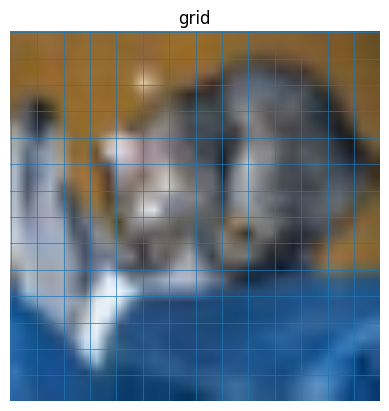

In [25]:
#이미지 패치 확인
show_img_with_patches(ck_img)

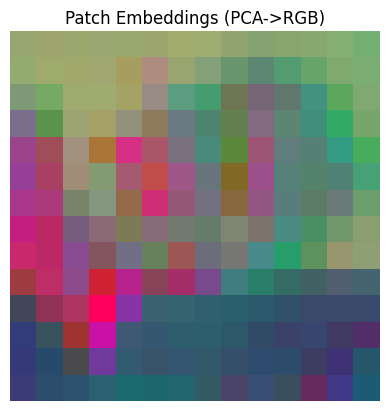

In [31]:
#패치 임베딩 시각화
pe=activations['patch_embed_out'][0]
grid=int(math.sqrt(pe.shape[0]))
show_patch_embedding_as_image(pe.numpy(),grid,grid)

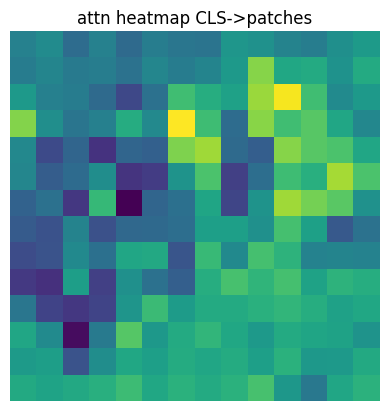

In [52]:
#한 블록 어텐션 히트맵(평균헤드)
bi=0
attn_b0=attentions[bi][0][0]#배치 0
attn_mean=attn_b0.mean(0).numpy()
show_attention_map(attn_mean)

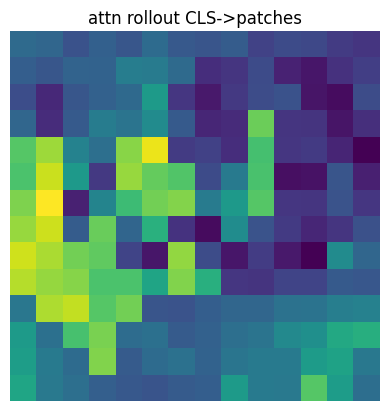

In [60]:
#어텐션 롤아웃
attn_per_block=[]
for bi in range(len(m.blocks)):
    A=attentions[bi][0][0].mean(0).numpy()
    attn_per_block.append(A)
roll=attention_rollout(attn_per_block)
show_rollout_to_patches(roll,grid,grid)

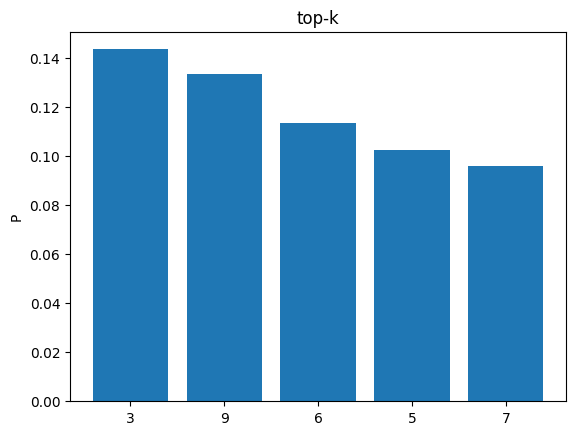

In [61]:
with torch.no_grad():
    logits=m(img[:1])[0]
show_topk_bar(logits,k=5,class_names=list(range(10)))

# Kvasir-SEG Data 
1. U-net 모델을 구축하여 학습 하여 모델을 완성하시오
2. 데이터셋을 분석하여 이미지와 내용을 정립하고 거기에 맞는 학습 구조를 설계하시오
3. 데이터는 반드시 로드를 이용하시오
4. 분할 성능 지표는 loss 와 mIoU값 을 이용하여 모델을 선정하시오
5. 추가 성능 지표로 모델 성능 평가